In [1]:
# HyperOpt 를 찾기 위한 기본 루틴 정리본 , 
# 본 파일을 save_as 이니셜_1.모델축약어_FindHO.ipynb 로 저장하세요~ ex) lkj_1.XGB_FindHO.ipynb

In [2]:
import sys

project_root = 'c:/big20/git/big20-ML-project2-team3/CreditCardFraud'

# sys.path에 추가 (모듈 import용)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [3]:
import os

import time
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')

# module_path = os.path.abspath(os.path.join('..'))
# if module_path not in sys.path:
#     sys.path.append(module_path)

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics         import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics         import roc_auc_score
from sklearn.metrics         import precision_recall_curve, classification_report
from sklearn.datasets         import make_classification

# Model import
from sklearn.tree           import DecisionTreeClassifier
from sklearn.ensemble       import RandomForestClassifier
from sklearn.ensemble       import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model   import LogisticRegression
from sklearn.linear_model   import LinearRegression
from sklearn.svm            import SVC
from sklearn.metrics        import classification_report
from xgboost                import XGBClassifier
from xgboost                import plot_importance
from lightgbm               import LGBMClassifier
from catboost               import CatBoostClassifier

# hyperopt 용
from hyperopt               import hp


# 사용자 Functions import
import HyperParams          as HP 
import utils.data_sampling  as ds 

from utils import user_utils    as uu
from utils import preprocessing as pp
from utils import data_sampling as ds
from utils import model_utils   as mu
from utils import modeling      as mo

In [4]:
# 결과 받을 딕셔너리
results = {}

In [5]:
#1. 데이터 로딩
raw_df = pp.ccf_load_data()

데이터 로드 성공: (284807, 31)


In [6]:
# 2. Time 컬럼 삭제 , 데이터,타겟 분리
X_features, y_target = pp.split_features_target(raw_df, cols= 'Time')

In [7]:
# 3. 이상치를 경계값으로 치환
cap_X_feature = pp.cap_outliers(X_features)

In [8]:
# 4.1 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = pp.data_split(cap_X_feature, y_target)

In [9]:
# 5.1 학습/검증 데이터 분리
X_tr, X_val, y_tr, y_val = pp.data_split(X_train, y_train, size=0.4)

In [ ]:
#6 하이퍼파라미터
tuner = uu.HyperOptTuner(max_evals=100, random_state=23)

# 모델별 스페이스 생성 : LightGBM
lgbm_search_space = {
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
    'num_leaves': hp.quniform('num_leaves', 31, 256, 1),
    'max_depth': hp.quniform('max_depth', 3, 10, 1),
    'n_estimators': hp.quniform('n_estimators', 100, 1000, 50),
    'feature_fraction': hp.uniform('feature_fraction', 0.5, 1.0),
    'bagging_fraction': hp.uniform('bagging_fraction', 0.5, 1.0),
    'bagging_freq': hp.quniform('bagging_freq', 0, 5, 1),
    'min_data_in_leaf': hp.quniform('min_data_in_leaf', 20, 200, 5),
    'lambda_l1': hp.uniform('lambda_l1', 0.0, 5.0),
    'lambda_l2': hp.uniform('lambda_l2', 0.0, 5.0),
    # 불균형 데이터 대응
    'scale_pos_weight': hp.choice('scale_pos_weight', [1, int(len(y_train)/sum(y_train))])
}

# 모델 생성 (LightGBM)
lgbm = LGBMClassifier()

# 파라미터 지정
best_params, best_lgbm, trials, exec_time = tuner.tune(
    lgbm, X_tr, y_tr, X_val, y_val, lgbm_search_space
)

# best모델로 결과출력
model_name = 'lgb_ho_best'
results[model_name] = uu.get_model_train_eval(
    best_lgbm, model_name, X_train, X_test, y_train, y_test, best_params
)

result_lgbm = '''
[[56478   386]
 [   18    80]] }
실행 시간: 1.5320014953613281
하이퍼파라미터: {
    'bagging_fraction': 0.8928311418280319, 
    'bagging_freq': 0, 
    'feature_fraction': 0.9900895952195329, 
    'lambda_l1': 0.3045393816732618, 
    'lambda_l2': 3.3928721015115566, 
    'learning_rate': 0.14435957617147147, 
    'max_depth': 5, 
    'min_data_in_leaf': 20, 
    'n_estimators': 100, 
    'num_leaves': 111, 
    'scale_pos_weight': 578, 
    'random_state': 23, 
    'n_jobs': -1
}
'''


LGBMClassifier 튜닝 시작
[LightGBM] [Warning] min_data_in_leaf is set=160, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=160
[LightGBM] [Warning] feature_fraction is set=0.5965749484346121, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5965749484346121
[LightGBM] [Warning] lambda_l1 is set=1.6420868771198043, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.6420868771198043
[LightGBM] [Warning] lambda_l2 is set=0.7277782946697364, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.7277782946697364
[LightGBM] [Warning] bagging_fraction is set=0.5576796500555039, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5576796500555039
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] min_data_in_leaf is set=160, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=160
[LightGBM] [Warning] feature_fraction is set=0.5965749

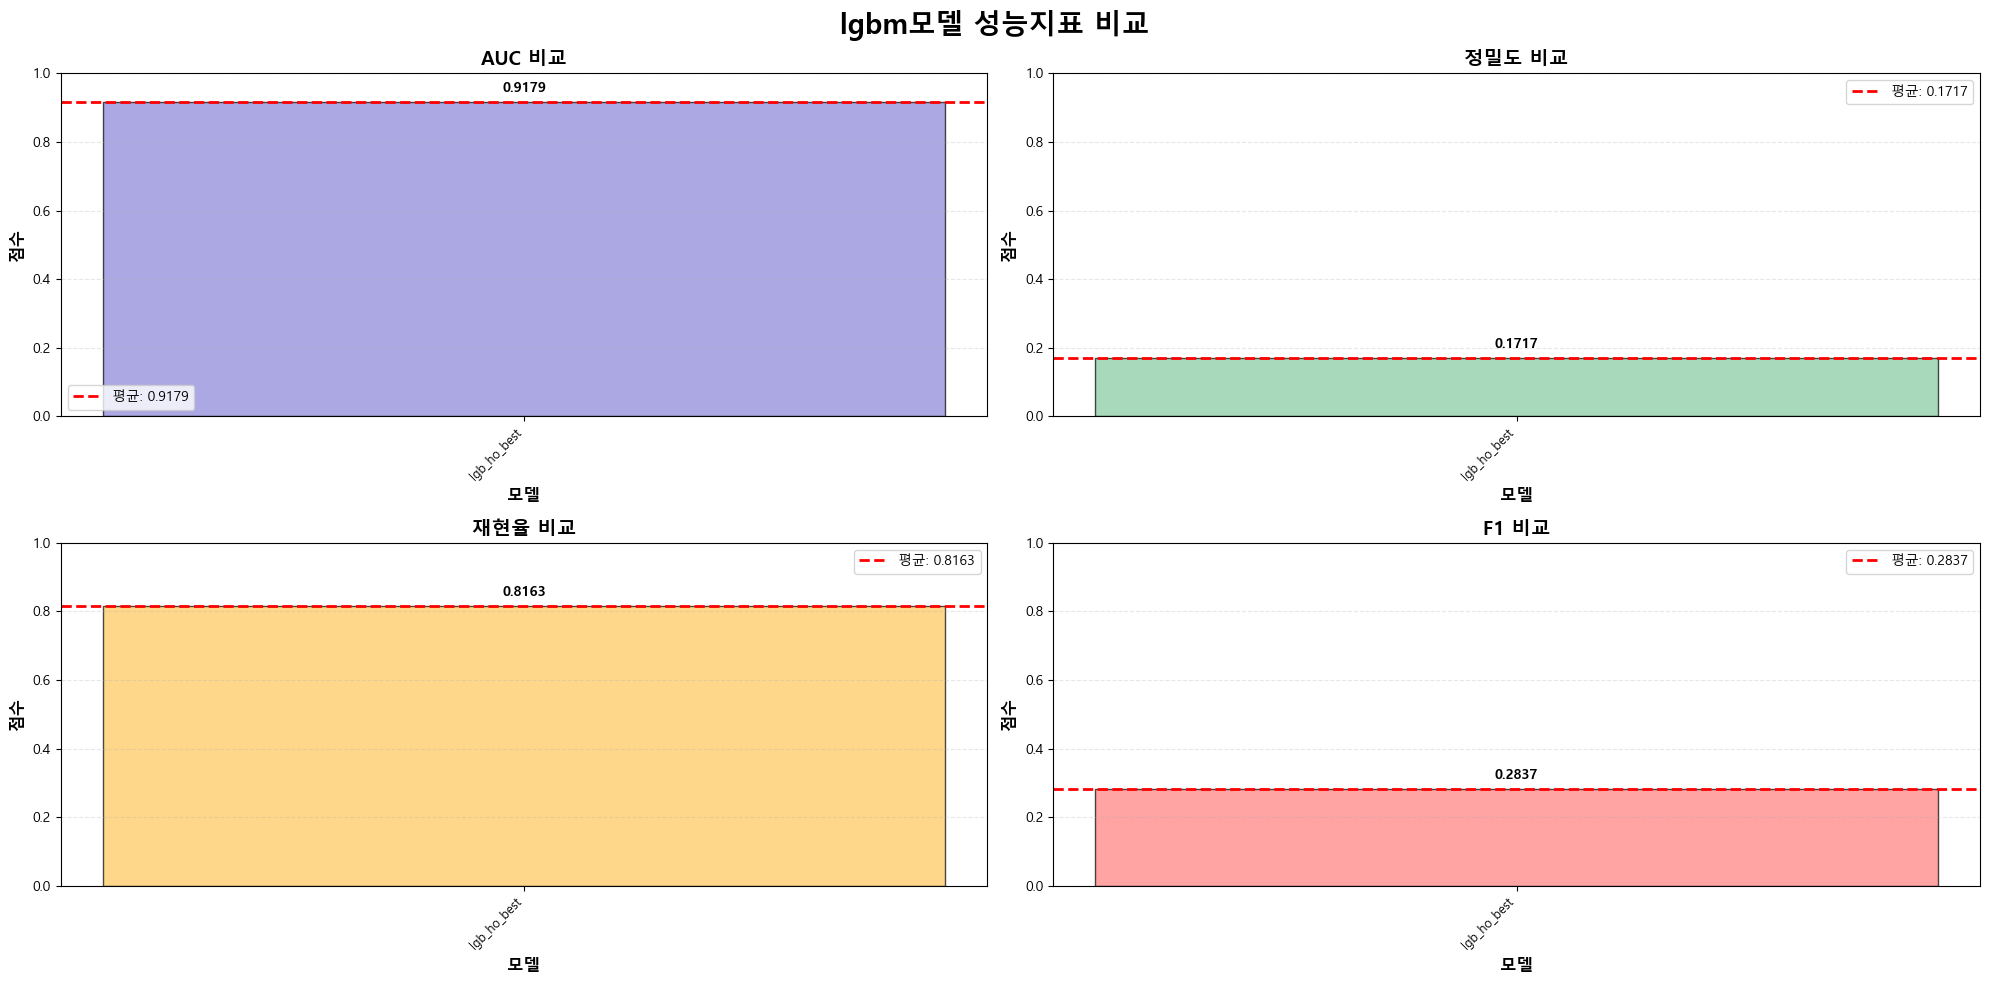


=== 지표별 통계 요약 ===

[AUC]
  최고: 0.9179 (lgb_ho_best)
  최저: 0.9179 (lgb_ho_best)
  평균: 0.9179
  표준편차: nan

[정밀도]
  최고: 0.1717 (lgb_ho_best)
  최저: 0.1717 (lgb_ho_best)
  평균: 0.1717
  표준편차: nan

[재현율]
  최고: 0.8163 (lgb_ho_best)
  최저: 0.8163 (lgb_ho_best)
  평균: 0.8163
  표준편차: nan

[F1]
  최고: 0.2837 (lgb_ho_best)
  최저: 0.2837 (lgb_ho_best)
  평균: 0.2837
  표준편차: nan


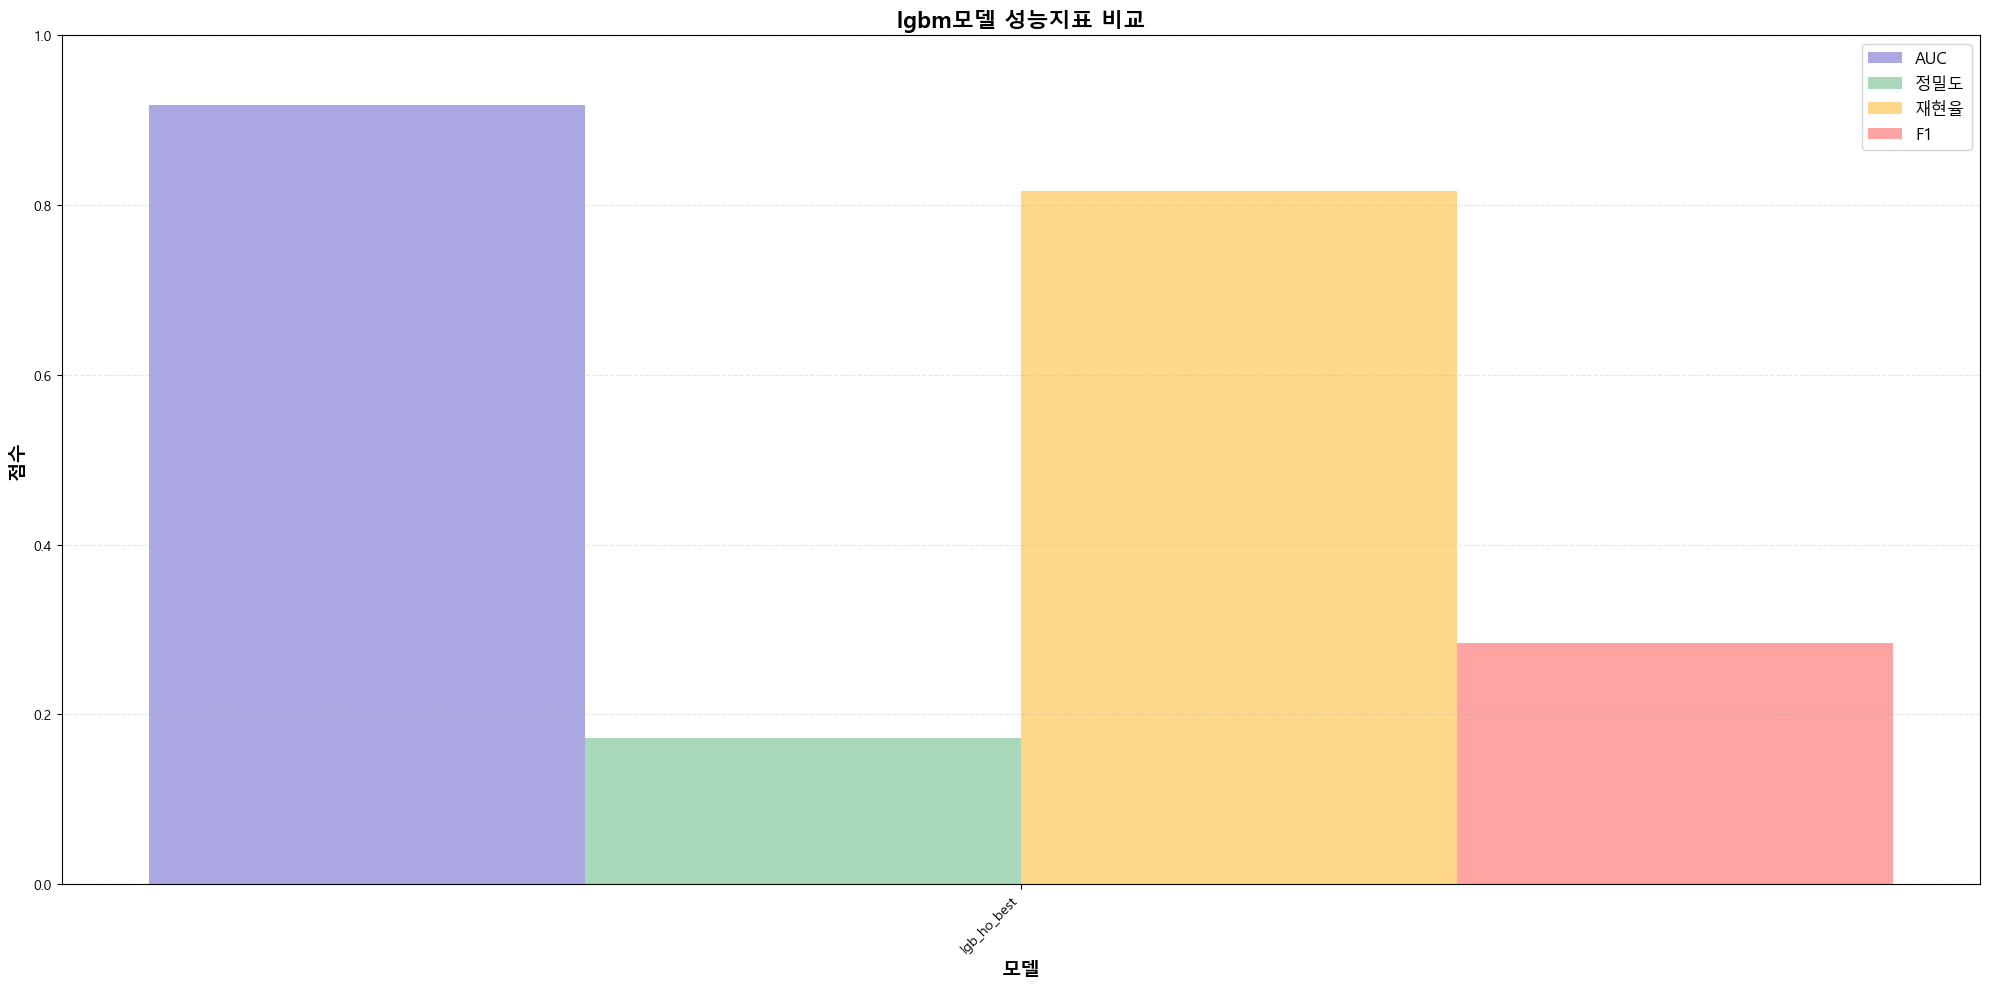


=== F1 Score 기준 상위 5개 모델 ===
                AUC     정밀도     재현율      F1
lgb_ho_best  0.9179  0.1717  0.8163  0.2837

그래프가 저장되었습니다: ../images/lgbm모델_성능지표_비교_2025_1129.png


In [12]:
# 7 시각화
mo.model_metrics_graph(results, 'lgbm모델 성능지표 비교')

In [ ]:
# thresholds별 튜닝 접근


'''
정밀도와 f1-score 결과가 매우 떨어져, threshold 를 조정하여 best_lgbm 에 적용
    - 현재는 0.5 기준으로 사기 여부를 판단.
    - Precision을 높이고 싶다면 threshold를 올려서 “더 확실한 경우만 사기”로 분류하도록 조정 가능.
'''

# 예측 확률
y_pred_proba = best_lgbm.predict_proba(X_test)[:,1]

thresholds = np.arange(0.1, 0.91, 0.1)  # 0.1 ~ 0.9
results_threshold = []

for thr in thresholds:
    y_pred_thr = (y_pred_proba >= thr).astype(int)
    precision = precision_score(y_test, y_pred_thr)
    recall = recall_score(y_test, y_pred_thr)
    f1 = f1_score(y_test, y_pred_thr)
    auc = roc_auc_score(y_test, y_pred_proba)

    results_threshold.append({
        'threshold': thr,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc
    })

# 결과 출력
import pandas as pd
df_thr = pd.DataFrame(results_threshold)
print(df_thr)

results_threshold = '''
   threshold  precision    recall        f1       auc
0        0.1   0.160321  0.816327  0.268007  0.917883
1        0.2   0.163599  0.816327  0.272572  0.917883
2        0.3   0.165289  0.816327  0.274914  0.917883
3        0.4   0.168421  0.816327  0.279232  0.917883
4        0.5   0.171674  0.816327  0.283688  0.917883
5        0.6   0.173160  0.816327  0.285714  0.917883
6        0.7   0.174292  0.816327  0.287253  0.917883
7        0.8   0.176339  0.806122  0.289377  0.917883
8        0.9   0.180365  0.806122  0.294776  0.917883
'''

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.9900895952195329, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9900895952195329
[LightGBM] [Warning] lambda_l1 is set=0.3045393816732618, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.3045393816732618
[LightGBM] [Warning] lambda_l2 is set=3.3928721015115566, reg_lambda=0.0 will be ignored. Current value: lambda_l2=3.3928721015115566
[LightGBM] [Warning] bagging_fraction is set=0.8928311418280319, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8928311418280319
[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0
   threshold  precision    recall        f1       auc
0        0.1   0.160321  0.816327  0.268007  0.917883
1        0.2   0.163599  0.816327  0.272572  0.917883
2        0.3   0.165289  0.816327  0.274

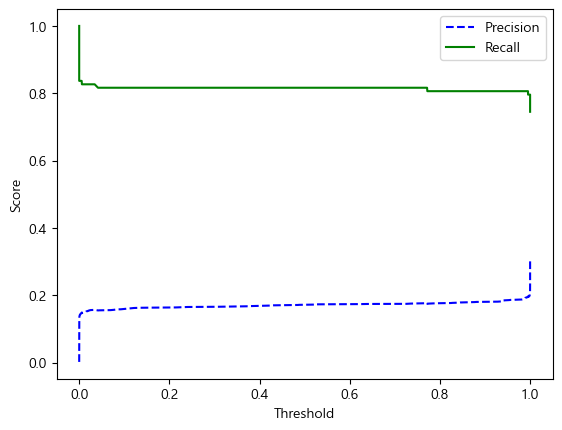

In [ ]:
# threshold 변화 적용시 Recall, Precision 결과 변화값 시각화

from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precisions, recalls, thr = precision_recall_curve(y_test, y_pred_proba)

plt.plot(thr, precisions[:-1], "b--", label="Precision")
plt.plot(thr, recalls[:-1], "g-", label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()